# Primeiro Trabalho Prático
**Classificação de Exoplanetas (Kepler / KOI)**

- **Disciplina:** Inteligência Artificial
- **Professor:** Cristiano Neves Rodrigues
- **Integrantes:** Ariel Inácio Jordão, Cauã Diniz, Lucca Pellegrini

## Objetivo

Queremos comparar seis métodos de classificação (Naïve Bayes, Decision Tree, k-NN, SVM, Random Forest e Gradient Tree Boosting) em um problema de classificação binária: distinguir candidatos a exoplanetas (KOIs) da sonda Kepler que são exoplanetas confirmados (`CONFIRMED`) de falsos positivos (`FALSE POSITIVE`). Para cada método, realizamos a variação de hiperparâmetros, a análise gráfica, e a discussão teórica, sempre usando validação cruzada *k-fold* estratificada com $k=5$ e, aplicando pré-processamento, quando necessário, dentro da pipeline de validação para evitar vazamento de dados.

## 1. Configuração e imports

In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

# Ferramentas para manipular e visualizar os dados
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    auc,
    classification_report,
    roc_curve,
)

# Ferramentas do sklearn
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Coisas auxiliares
from sympy import isprime

RANDOM_STATE = 67
N_SPLITS = 5

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

np.random.seed(RANDOM_STATE)

## 2. Carregamento dos dados

In [2]:
df = pd.read_csv("koi_data.csv")
print("Dimensões:", df.shape)
df.head()

Dimensões: (5202, 43)


,kepoi_name,koi_disposition,koi_period,koi_impact,koi_duration,koi_depth,koi_ror,koi_srho,koi_prad,koi_sma,...,koi_fwm_srao,koi_fwm_sdeco,koi_fwm_prao,koi_fwm_pdeco,koi_dicco_mra,koi_dicco_mdec,koi_dicco_msky,koi_dikco_mra,koi_dikco_mdec,koi_dikco_msky
0,K00752.01,CONFIRMED,9.48804,0.146,2.95750,615.8,0.02234,3.20796,2.26,0.0853,...,0.430,0.940,-0.00020,-0.00055,-0.010,0.200,0.200,0.080,0.310,0.320
1,K00752.02,CONFIRMED,54.41838,0.586,4.50700,874.8,0.02795,3.02368,2.83,0.2734,...,-0.630,1.230,0.00066,-0.00105,0.390,0.000,0.390,0.490,0.120,0.500
2,K00754.01,FALSE POSITIVE,1.73695,1.276,2.40641,8079.2,0.38739,0.22080,33.46,0.0267,...,-0.111,0.002,0.00302,-0.00142,-0.249,0.147,0.289,-0.257,0.099,0.276
3,K00755.01,CONFIRMED,2.52559,0.701,1.65450,603.3,0.02406,1.98635,2.75,0.0374,...,-0.010,0.230,0.00008,-0.00007,0.030,-0.090,0.100,0.070,0.020,0.070
4,K00114.01,FALSE POSITIVE,7.36179,1.169,5.02200,233.7,0.18339,0.00485,39.21,0.0820,...,-13.450,24.090,0.00303,-0.00555,-4.506,7.710,8.930,-4.537,7.713,8.948


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5202 entries, 0 to 5201
Data columns (total 43 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   kepoi_name        5202 non-null   str    
 1   koi_disposition   5202 non-null   str    
 2   koi_period        5202 non-null   float64
 3   koi_impact        5202 non-null   float64
 4   koi_duration      5202 non-null   float64
 5   koi_depth         5202 non-null   float64
 6   koi_ror           5202 non-null   float64
 7   koi_srho          5202 non-null   float64
 8   koi_prad          5202 non-null   float64
 9   koi_sma           5202 non-null   float64
 10  koi_incl          5202 non-null   float64
 11  koi_teq           5202 non-null   float64
 12  koi_insol         5202 non-null   float64
 13  koi_dor           5202 non-null   float64
 14  koi_max_sngle_ev  5202 non-null   float64
 15  koi_max_mult_ev   5202 non-null   float64
 16  koi_model_snr     5202 non-null   float64
 17  koi_st

In [4]:
# Comprovando que não há valores ausentes no conjunto de dados
print("Total de valores ausentes:", df.isna().sum().sum())

Total de valores ausentes: 0


In [5]:
# Distribuição das classes
class_counts = df["koi_disposition"].value_counts()
class_counts

koi_disposition
FALSE POSITIVE    3098
CONFIRMED         2104
Name: count, dtype: int64

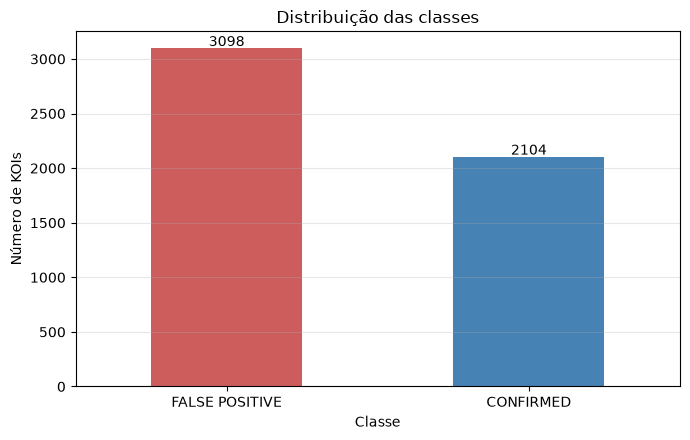

koi_disposition
FALSE POSITIVE    0.59554
CONFIRMED         0.40446
Name: count, dtype: float64


In [6]:
fig, ax = plt.subplots()
class_counts.plot(kind="bar", ax=ax, color=["indianred", "steelblue"])
ax.set_title("Distribuição das classes")
ax.set_xlabel("Classe")
ax.set_ylabel("Número de KOIs")
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 20, str(v), ha="center")
plt.xticks(rotation=0)
ax.grid(False, axis="x")
plt.tight_layout()
plt.show()

proporcao = class_counts / class_counts.sum()
print(proporcao)

As classes estão levemente desbalanceadas, com cerca de 59,6% dos KOIs sendo falsos positivos e 40,4% sendo exoplanetas confirmados.

In [7]:
# Separamos entre features (X) e rótulo (y).
# Convertemos o rótulo para binário, com 1 para classe positiva,
# e 0 para o falso positivo
X = df.drop(columns=["kepoi_name", "koi_disposition"])
y = (df["koi_disposition"] == "CONFIRMED").astype(int)

feature_names = X.columns.tolist()
print(f"Número de features: {len(feature_names)}")
print(f"Número de amostras: {len(X)}")

Número de features: 41
Número de amostras: 5202


In [8]:
# Estatísticas descritivas das features.
desc = X.describe().T  # Transposta para ficar mais fácil de ler
desc["skew"] = X.skew()
desc[["mean", "std", "min", "max", "skew"]]

,mean,std,min,max,skew
koi_period,37.032237,88.417985,0.30694,1.071233e+03,4.015403
koi_impact,0.717106,2.628207,0.00000,1.008060e+02,31.526734
koi_duration,5.607025,6.962634,0.10460,1.385400e+02,6.587950
koi_depth,21340.318993,66989.808550,0.80000,8.642600e+05,4.596848
koi_ror,0.235205,2.586213,0.00129,9.987065e+01,32.575624
koi_srho,3.415370,25.131368,0.00004,9.187524e+02,27.811841
koi_prad,112.230798,3699.799318,0.08000,2.003460e+05,47.634642
koi_sma,0.158146,0.241792,0.00720,2.034500e+00,3.115686
koi_incl,81.181413,16.308839,2.29000,9.000000e+01,-2.759616
koi_teq,1143.721069,775.788868,92.00000,9.791000e+03,2.151209


Vale notar a grande diferença entre as escalas de várias colunas, além da forte assimetria (*skew*) de algumas. Veja os histogramas abaixo:

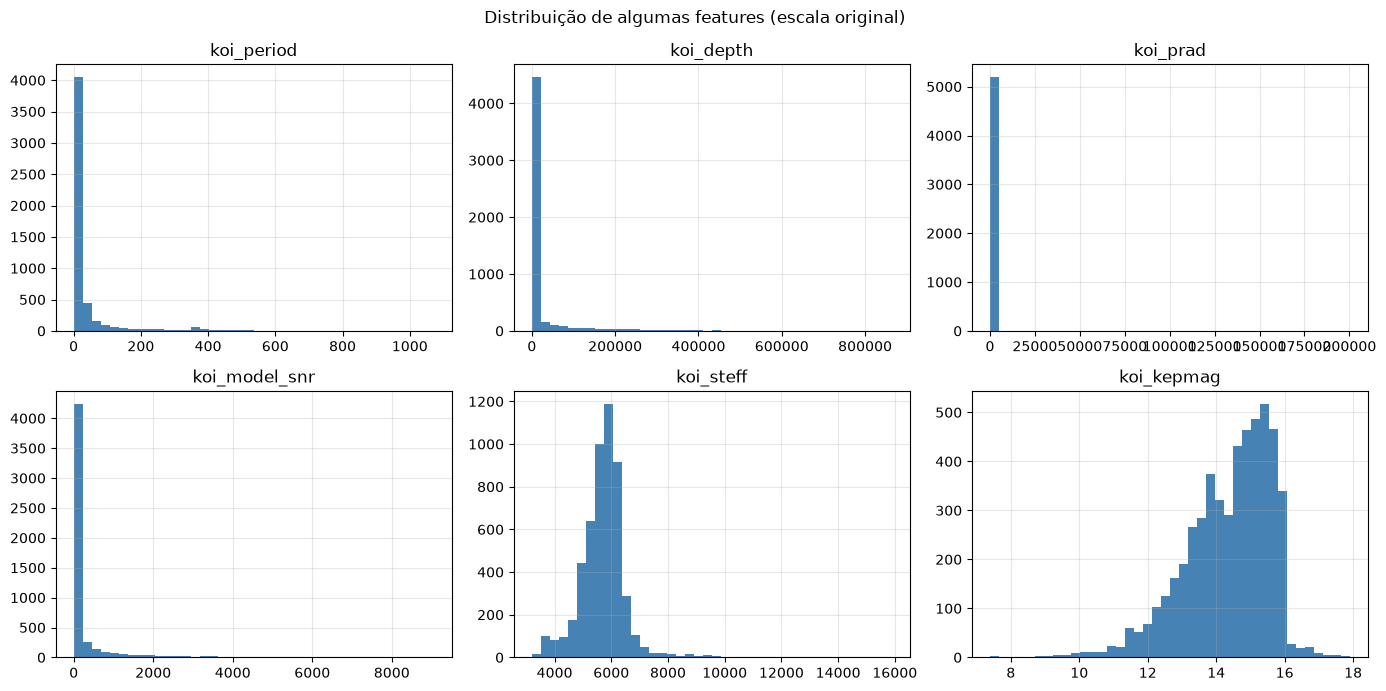

In [9]:
# Histogramas de algumas features para ilustrar a diferença de escala e a assimetria
cols_exemplo = [
    "koi_period",
    "koi_depth",
    "koi_prad",
    "koi_model_snr",
    "koi_steff",
    "koi_kepmag",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), cols_exemplo):
    ax.hist(X[col], bins=40, color="steelblue")
    ax.set_title(col)
plt.suptitle("Distribuição de algumas features (escala original)")
plt.tight_layout()
plt.show()

Pode-se observar que: **(i)** As features têm escalas muito diferentes entre si; por exemplo, `koi_period` varia até ~1000, enquanto `koi_smet` varia entre -2,5 e 0,6; e **(ii)** muitas features são fortemente assimétricas (são os histogramas com uma cauda longa e curta à direita), o que é de se esperar em grandezas astronômicas.

Esses dois pontos motivam a etapa de pré-processamento (na Seção 4, abaixo): métodos baseados em distância ou em produtos internos (k-NN, SVM) e métodos probabilísticos que supõem features aproximadamente gaussianas (Naïve Bayes) são sensíveis a essas características, enquanto métodos baseados em árvores (Decision Tree, Random Forest, Gradient Boosting) são invariantes a transformações monotônicas das features.

Geramos também uma matriz de correlação entre as features, o que pode ser útil para entender o problema:

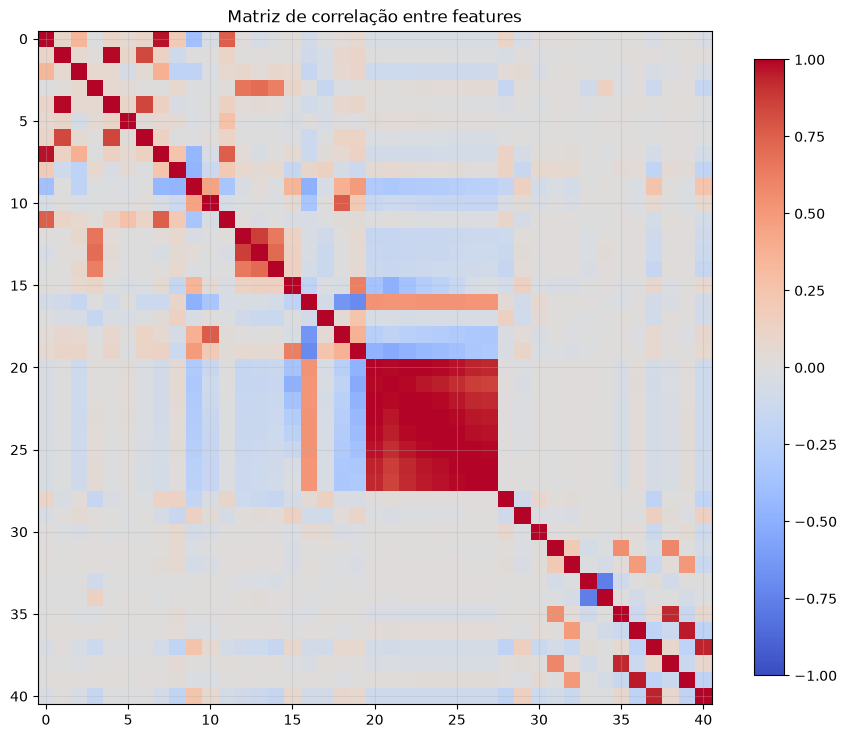

In [10]:
corr = X.corr()
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Matriz de correlação entre features")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 3. Estratégia de avaliação

### Validação cruzada

Usaremos validação cruzada estratificada com $k=5$ (`StratifiedKFold`) para todos os experimentos. A estratificação deve garantir que a proporção de classes em cada fold seja semelhante à do conjunto completo. Usamos a mesma partição (mesmo `random_state`) em todos os experimentos para que as comparações entre métodos sejam justas.

### Métricas

Além da acurácia, decidimos reportar: **(i)** a **precisão**: dentre os KOIs que o modelo classificou como `CONFIRMED`, qual fração é de fato um exoplaneta confirmado, relevante para evitar falsos positivos de exoplaneta; **(ii)** a **revocaçao** (_recall_): dentre os exoplanetas de fato confirmados, qual fração o modelo conseguiu identificar corretamente, relevante para não **descartar** candidatos que são exoplanetas reais; **(iii)** a **F1-score**: média harmônica entre precisão e revocação, útil como métrica única de resumo quando não há uma preferência clara por um dos dois tipos de erro, e as classes não são extremamente desbalanceadas; e **(iv)** a **AUC-ROC**: capacidade do modelo de ranquear corretamente exemplos positivos acima de negativos, independentemente do limiar de decisão escolhido, especialmente relevante para comparar modelos de forma agnóstica ao *threshold* e é robusta ao desbalanceamento moderado das classes.

### Por que não usamos só a acurácia?

A acurácia representa a proporção total de classificações corretas. Apesar de ser uma métrica simples e útil, ela sempre pode esconder problemas quando existe um desbalanceamento entre as classes. No nosso conjunto de dados, aproximadamente 60% das observações pertencem à classe majoritária, `FALSE POSITIVE`. Portanto, um modelo que simplesmente classificasse todas as observações como `FALSE POSITIVE` já conseguiria uma acurácia próxima de 60%, mesmo sem aprender a distinguir corretamente as duas classes.

Além disso, a acurácia não mostra qual tipo de erro o modelo está cometendo. Um modelo pode apresentar uma boa acurácia e, ainda assim, produzir muitos falsos positivos ou muitos falsos negativos. Por esse motivo, utilizaremos acurácia, precisão, revocação, F1-score e AUC-ROC em conjunto. Dessa forma, conseguimos obter uma visão mais completa do comportamento de cada modelo.

### Como evitar vazamento de dados

Sempre que um experimento envolver pré-processamento, usamos `sklearn.pipeline.Pipeline`/`make_pipeline`, de forma que o `fit` da transformação seja feito _apenas_ com os dados de treino de cada fold, e depois aplicado (`transform`) nos dados de teste do mesmo fold. Isso é feito automaticamente pelo `cross_validate` quando passamos um pipeline como estimador.

In [11]:
# CV compartilhada por todos os experimentos, para comparação justa entre métodos
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Métricas usadas em todos os experimentos
SCORING = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}


def avaliar_modelo(estimator, X=X, y=y, cv=cv, scoring=SCORING, return_estimator=False):
    """Roda validação cruzada k-fold e devolve um DataFrame com a média e o desvio
    padrão de cada métrica de teste ao longo dos folds."""
    resultado = cross_validate(
        estimator,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_estimator=return_estimator,
    )
    linhas = {}
    for nome_metrica in scoring:
        chave = f"test_{nome_metrica}"
        linhas[nome_metrica] = {
            "media": resultado[chave].mean(),
            "desvio": resultado[chave].std(),
        }
    resumo = pd.DataFrame(linhas).T
    return resumo, resultado


def resumo_para_linha(nome, resumo):
    """Converte o resumo (média e desvio) em uma linha para a tabela
    comparativa final."""
    linha = {"modelo": nome}
    for metrica in resumo.index:
        linha[metrica] = resumo.loc[metrica, "media"]
        linha[metrica + "_std"] = resumo.loc[metrica, "desvio"]
    return linha


resultados_finais = []  # Acumula um resumo por método para a comparação da Seção 11

## 4. Pré-processamento

Na Seção 2, vimos que as features têm escalas muito diferentes e são fortemente assimétricas. Isso afeta métodos de formas diferentes. Primeiramente, o *Naïve Bayes (Gaussian)* supõe que cada feature, condicionada à classe, segue uma distribuição normal. Features muito assimétricas violam essa suposição. Em segundo lugar, *k-NN* e *SVM* dependem de distâncias ou produtos internos entre exemplos. Sem normalização, features com escala maior (como, por exemlpo, `koi_depth`, na casa das dezenas de milhares) dominariam completamente o cálculo da distância, tornando features de menor escala (como `koi_smet`) praticamente irrelevantes. Finalmente, *Decision Trees*, *Random Forests* e *Gradient Boosting* particionam o espaço de features com base em limiares (*thresholds*) por atributo. Esses métodos são invariantes a qualquer transformação monotônica aplicada a uma feature individualmente (como padronização ou transformação de potência), pois a ordem dos valores dentro de cada atributo não se altera. Logo, não há necessidade (nem prejuízo) de escalonar os dados para esses métodos.

Testamos duas abordagens de pré-processamento para os modelos sensíveis a escala: primeiro, usamos `StandardScaler` (normaliza para média 0 e desvio padrão 1); depois, `PowerTransformer` ([transformação de Yeo-Johnson](https://en.wikipedia.org/w/index.php?title=Power_transform&oldid=1349174835&useskin=vector#Yeo–Johnson_transformation)), que além de padronizar, também reduz a assimetria das distribuições, e as aproxima de uma gaussiana. Comparamos rapidamente as duas opções abaixo, usando o k-NN e o Naïve Bayes como sondas, com a ideia de escolhermos a que produzir melhor resultado de validação cruzada.

In [12]:
comparacao_prep = []
preprocessadores = {
    "Nenhum pré-processamento": None,
    "StandardScaler": StandardScaler(),
    "Yeo-Johnson": PowerTransformer(method="yeo-johnson"),
}

for nome_prep, prep in preprocessadores.items():
    for nome_modelo, modelo in [
        ("GaussianNB", GaussianNB()),
        ("kNN (k=5)", KNeighborsClassifier(n_neighbors=5)),
    ]:
        estimator = modelo if prep is None else make_pipeline(prep, modelo)
        resumo, _ = avaliar_modelo(estimator)
        comparacao_prep.append(
            {
                "pré-processamento": nome_prep,
                "modelo": nome_modelo,
                "acurácia": resumo.loc["accuracy", "media"],
                "f1": resumo.loc["f1", "media"],
                "roc_auc": resumo.loc["roc_auc", "media"],
            }
        )

pd.DataFrame(comparacao_prep).sort_values(
    ["modelo", "roc_auc"], ascending=[True, False]
)

,pré-processamento,modelo,acurácia,f1,roc_auc
4,Yeo-Johnson,GaussianNB,0.923682,0.912095,0.983240
2,StandardScaler,GaussianNB,0.916568,0.904091,0.961761
0,Nenhum pré-processamento,GaussianNB,0.799113,0.797001,0.937229
5,Yeo-Johnson,kNN (k=5),0.948865,0.939366,0.984189
3,StandardScaler,kNN (k=5),0.896577,0.883489,0.951240
1,Nenhum pré-processamento,kNN (k=5),0.784315,0.746553,0.850259


O `PowerTransformer` supera claramente tanto a ausência de pré-processamento quanto o `StandardScaler` simples, para ambos os modelos sonda. Isso é consistente com a forte assimetria observada nos histogramas da Seção 2: ao aproximar as distribuições de uma gaussiana, o `PowerTransformer` favorece tanto o Naïve Bayes, cuja suposição de normalidade fica mais próxima de ser satisfeita, quanto o k-NN, cuja noção de distância deixa de ser dominada por caudas longas de poucas amostras. Por causa disso, decidimos usar `PowerTransformer` como etapa de pré-processamento para Naïve Bayes, k-NN e SVM. Para Decision Tree, Random Forest e Gradient Boosting, não aplicaremos nenhum pré-processamento, pelo motivo de invariância discutido acima.

Em todos os casos, o pré-processamento é encapsulado em uma `Pipeline` (via `make_pipeline`) e ajustado dentro de cada fold da validação cruzada, para impedir o vazamento de dados.

## 5. Naïve Bayes (baseline)

O Naïve Bayes Gaussiano presume independência condicional entre as features dada a classe, e também supõe que cada feature segue uma distribuição normal dentro de cada classe. É um modelo simples, rápido de treinar, sem hiperparâmetros relevantes para ajustar, e por isso o usamos como _baseline_: qualquer método mais sofisticado deve superá-lo.

In [13]:
pipeline_nb = make_pipeline(PowerTransformer(method="yeo-johnson"), GaussianNB())
resumo_nb, resultado_nb = avaliar_modelo(pipeline_nb)
resumo_nb

,media,desvio
accuracy,0.923682,0.005669
precision,0.854124,0.009692
recall,0.978614,0.007199
f1,0.912095,0.006113
roc_auc,0.983240,0.003944


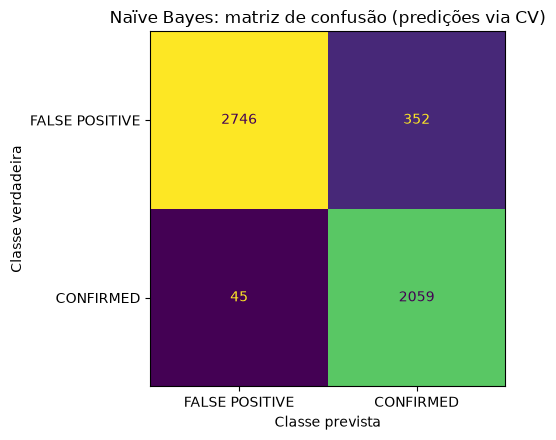

                precision    recall  f1-score   support

FALSE POSITIVE       0.98      0.89      0.93      3098
     CONFIRMED       0.85      0.98      0.91      2104

      accuracy                           0.92      5202
     macro avg       0.92      0.93      0.92      5202
  weighted avg       0.93      0.92      0.92      5202



In [14]:
resultados_finais.append(resumo_para_linha("Naïve Bayes", resumo_nb))

# Matriz de confusão agregada via predições obtidas por validação cruzada
# (cross_val_predict também respeita os folds, ou seja, cada predição é feita
# por um modelo que não viu aquele exemplo durante o treino)
y_pred_nb = cross_val_predict(pipeline_nb, X, y, cv=cv, n_jobs=-1)

fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(
    y, y_pred_nb, display_labels=["FALSE POSITIVE", "CONFIRMED"], ax=ax, colorbar=False
)
ax.set_ylabel("Classe verdadeira")
ax.set_xlabel("Classe prevista")
ax.set_title("Naïve Bayes: matriz de confusão (predições via CV)")
ax.grid(False)
plt.tight_layout()
plt.show()

print(classification_report(y, y_pred_nb, target_names=["FALSE POSITIVE", "CONFIRMED"]))

O Naïve Bayes já atinge um desempenho razoável, com acurácia e F1 acima de 0,90, o que sugere que o problema é facilmente separável com as features disponíveis. Ainda assim, a suposição de independência entre features (que sabemos ser violada, já que vimos correlações relevantes na matriz da Seção 2) limita seu desempenho frente a modelos mais flexíveis, como veremos a seguir.

## 6. Decision Tree

### **Experimento:** variação da profundidade máxima

A profundidade máxima controla quantas vezes a árvore pode particionar recursivamente o espaço de features. Uma árvore rasa (baixo `max_depth`) tem poucas fronteiras de decisão e tende a underfitting . Uma árvore muito profunda, ou sem limite, pode se ajustar até a ruídos específicos do conjunto de treino, gerando *overfitting*, e alta variância. Não aplicamos pré-processamento aqui, pois árvores de decisão são invariantes a transformações monotônicas de cada feature.

In [15]:
profundidades = [i + 1 for i in range(20)] + [None]
linhas_dt = []

for prof in profundidades:
    modelo = DecisionTreeClassifier(max_depth=prof, random_state=RANDOM_STATE)
    resumo, resultado = avaliar_modelo(modelo)
    # Desempenho em treino (média entre os folds), para ilustrar overfitting
    resultado_treino = cross_validate(
        modelo, X, y, cv=cv, scoring=SCORING, n_jobs=-1, return_train_score=True
    )
    linhas_dt.append(
        {
            "max_depth": prof if prof is not None else "Ilimitada",
            "max_depth_num": prof if prof is not None else 30,  # Somente para o plot!
            "acc_teste": resumo.loc["accuracy", "media"],
            "acc_treino": resultado_treino["train_accuracy"].mean(),
            "f1_teste": resumo.loc["f1", "media"],
            "roc_auc_teste": resumo.loc["roc_auc", "media"],
            "std_acc_teste": resumo.loc["accuracy", "desvio"],
        }
    )

df_dt = pd.DataFrame(linhas_dt)
df_dt

,max_depth,max_depth_num,acc_teste,acc_treino,f1_teste,roc_auc_teste,std_acc_teste
0,1,1,0.739519,0.749087,0.736675,0.765393,0.023804
1,2,2,0.883701,0.885909,0.858083,0.911320,0.032074
2,3,3,0.929067,0.934785,0.914696,0.952985,0.007014
3,4,4,0.944636,0.954008,0.932442,0.965439,0.003589
4,5,5,0.946175,0.965013,0.934671,0.963967,0.005763
5,6,6,0.949249,0.973472,0.938362,0.960674,0.005357
6,7,7,0.949058,0.980248,0.937896,0.953581,0.005337
7,8,8,0.946943,0.985438,0.935335,0.943631,0.004492
8,9,9,0.948865,0.989427,0.937500,0.940508,0.005977
9,10,10,0.949251,0.991590,0.937874,0.940557,0.004604


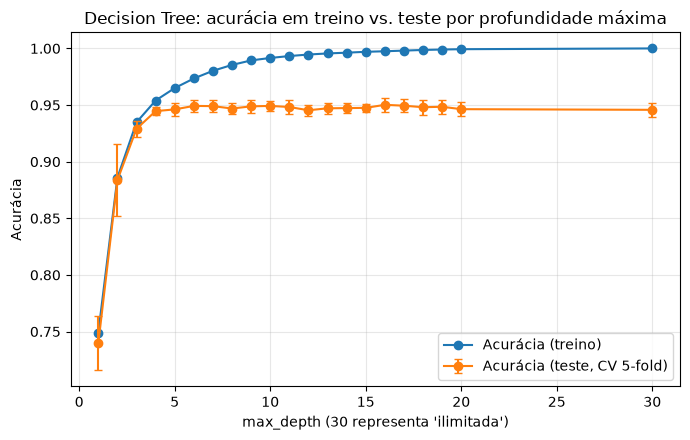

In [16]:
fig, ax = plt.subplots()
ax.plot(
    df_dt["max_depth_num"], df_dt["acc_treino"], marker="o", label="Acurácia (treino)"
)
ax.errorbar(
    df_dt["max_depth_num"],
    df_dt["acc_teste"],
    yerr=df_dt["std_acc_teste"],
    marker="o",
    label="Acurácia (teste, CV 5-fold)",
    capsize=3,
)
ax.set_xlabel("max_depth (30 representa 'ilimitada')")
ax.set_ylabel("Acurácia")
ax.set_title("Decision Tree: acurácia em treino vs. teste por profundidade máxima")
ax.legend()
plt.tight_layout()
plt.show()

O gráfico mostra o padrão clássico de viés-variância: para `max_depth` pequeno (em torno de 1–3), tanto a acurácia de treino quanto a de teste são baixas e próximas entre si, o que ilustra *underfitting*: a árvore é simples demais para capturar a estrutura dos dados, o que causa alto viés e baixa variância. Conforme `max_depth` aumenta, a acurácia de treino sobe rapidamente até atingir quase 100%, pois a árvore já pode isolar cada exemplo de treino em uma folha, enquanto a acurácia de teste sobe até um ponto e depois estagna ou piora ligeiramente; a partir daí, a árvore está memorizando particularidades do treino em vez de aprender padrões que generalizam, o que ilustra *overfitting*, e causa alta variância. Finalmente, a árvore com profundidade ilimitada tem acurácia de treino igual a 100%, mas o desempenho de teste não é o melhor entre as opções testadas, o que, mais uma vez, confirma o *overfitting*.

Escolhemos a profundidade que maximiza a métrica de teste como o melhor compromisso entre viés e variância:

In [17]:
melhor_linha_dt = df_dt.loc[df_dt["f1_teste"].idxmax()]
print("Melhor max_depth (por F1 de teste):", melhor_linha_dt["max_depth"])
print(melhor_linha_dt[["acc_teste", "f1_teste", "roc_auc_teste"]])

melhor_max_depth = (
    None
    if melhor_linha_dt["max_depth"] == "Ilimitada"
    else int(melhor_linha_dt["max_depth"])
)
modelo_dt_final = DecisionTreeClassifier(
    max_depth=melhor_max_depth, random_state=RANDOM_STATE
)
resumo_dt_final, _ = avaliar_modelo(modelo_dt_final)
resultados_finais.append(
    resumo_para_linha(
        f"Decision Tree (max_depth={melhor_linha_dt['max_depth']})", resumo_dt_final
    )
)
resumo_dt_final

Melhor max_depth (por F1 de teste): 16
acc_teste        0.950211
f1_teste         0.938592
roc_auc_teste    0.938262
Name: 15, dtype: object


,media,desvio
accuracy,0.950211,0.006005
precision,0.936811,0.012701
recall,0.940593,0.011909
f1,0.938592,0.007281
roc_auc,0.938262,0.007263


Visualização dos primeiros três níveis da árvore de decisão:

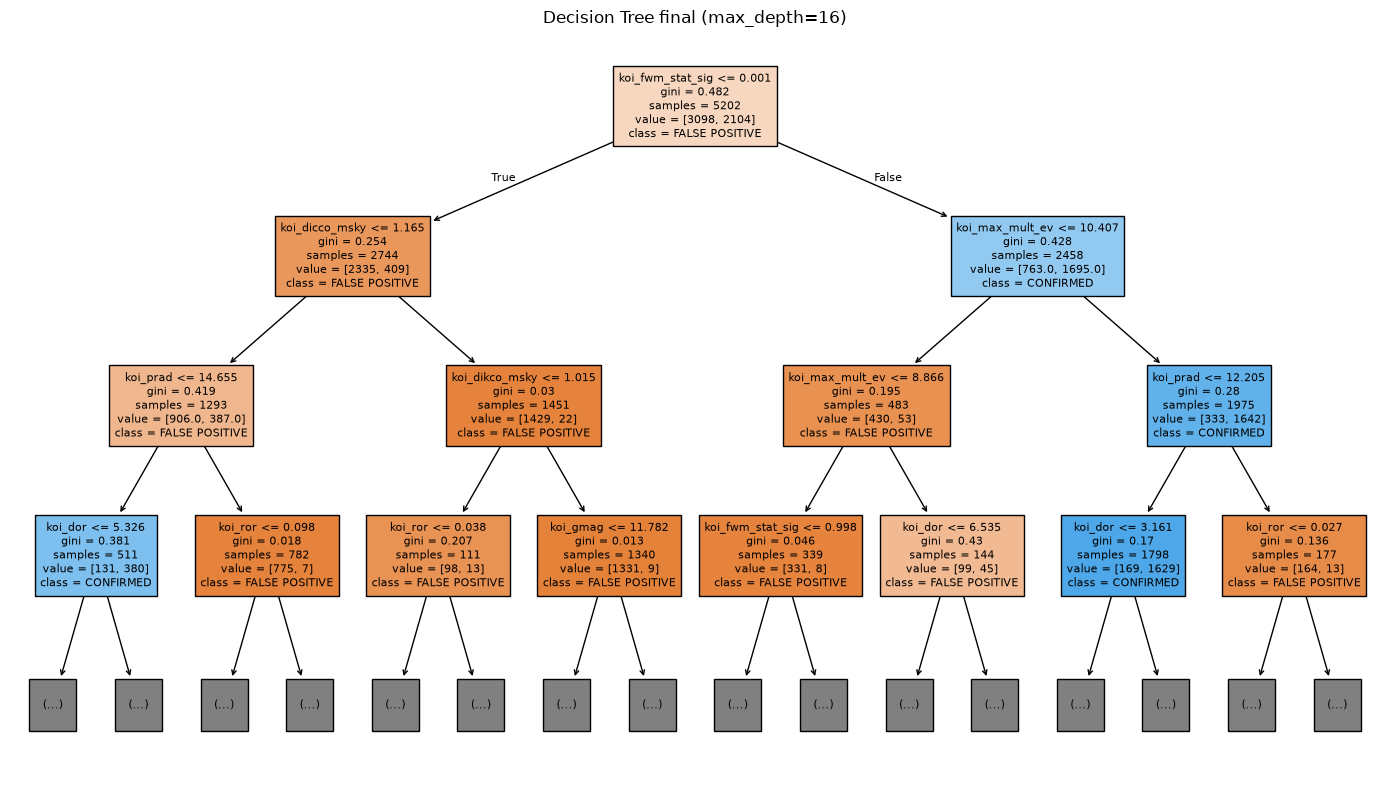

In [18]:
modelo_dt_final.fit(X, y)
fig, ax = plt.subplots(figsize=(14, 8))
plot_tree(
    modelo_dt_final,
    max_depth=3,
    feature_names=feature_names,
    class_names=["FALSE POSITIVE", "CONFIRMED"],
    filled=True,
    fontsize=8,
    ax=ax,
)
ax.set_title(f"Decision Tree final (max_depth={melhor_linha_dt['max_depth']})")
plt.tight_layout()

## 7. k-Nearest Neighbors (k-NN)

### **Experimento:** variação do número de vizinhos

O k-NN classifica um exemplo pela votação dos $k$ vizinhos mais próximos no espaço de features. Valores pequenos de $k$ tornam o modelo muito sensível a ruído e a exemplos individuaism, o que tende a causar fronteiras de decisão muito irregulares, alta variância, e tendência a overfitting. Valores grandes de $k$ suavizam demais a fronteira de decisão, levando em conta vizinhos cada vez mais distantes e menos relevantes, o que causa alto viés, e tendência a underfitting, podendo inclusive ser dominado pela classe majoritária quando $k$ se aproxima do tamanho do conjunto.

Como o k-NN depende diretamente da distância euclidiana entre exemplos, usamos o pipeline com `PowerTransformer`, pelas razões explicadas na Seção 4.

In [19]:
# Usamos números primos de vizinhos
valores_k = [i for i in range(100) if isprime(i)]
linhas_knn = []

for k in valores_k:
    modelo = make_pipeline(
        PowerTransformer(method="yeo-johnson"), KNeighborsClassifier(n_neighbors=k)
    )
    resumo, _ = avaliar_modelo(modelo)
    linhas_knn.append(
        {
            "k": k,
            "acuracia": resumo.loc["accuracy", "media"],
            "std_acuracia": resumo.loc["accuracy", "desvio"],
            "f1": resumo.loc["f1", "media"],
            "roc_auc": resumo.loc["roc_auc", "media"],
        }
    )

df_knn = pd.DataFrame(linhas_knn)
df_knn

,k,acuracia,std_acuracia,f1,roc_auc
0,2,0.948865,0.007821,0.936426,0.969843
1,3,0.946942,0.007003,0.936880,0.978563
2,5,0.948865,0.006757,0.939366,0.984189
3,7,0.948288,0.007965,0.938743,0.987364
4,11,0.943480,0.008815,0.933404,0.988702
5,13,0.943096,0.007978,0.933066,0.988968
6,17,0.939827,0.009854,0.929426,0.989312
7,19,0.938290,0.008777,0.927669,0.989640
8,23,0.938289,0.009851,0.927656,0.989582
9,29,0.936369,0.006854,0.925662,0.989441


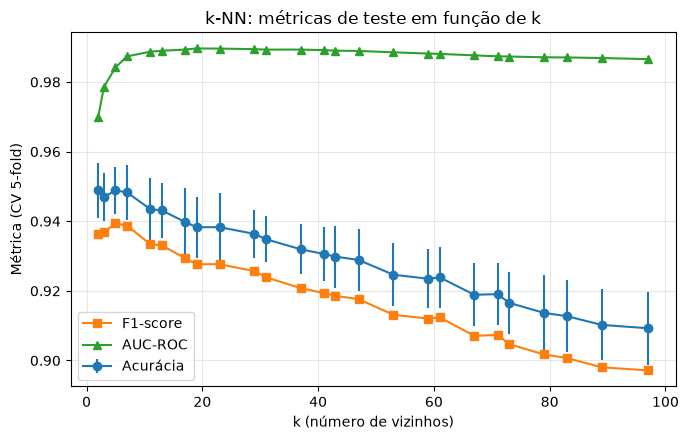

In [20]:
fig, ax = plt.subplots()
ax.errorbar(
    df_knn["k"],
    df_knn["acuracia"],
    yerr=df_knn["std_acuracia"],
    marker="o",
    label="Acurácia",
)
ax.plot(df_knn["k"], df_knn["f1"], marker="s", label="F1-score")
ax.plot(df_knn["k"], df_knn["roc_auc"], marker="^", label="AUC-ROC")
ax.set_xlabel("k (número de vizinhos)")
ax.set_ylabel("Métrica (CV 5-fold)")
ax.set_title("k-NN: métricas de teste em função de k")
ax.legend()
plt.tight_layout()
plt.show()

Como previsto acima, o desempenho é baixo para $k=1$ (mais sensível a ruído, cada previsão depende de um único vizinho, o que aumenta a variância) e melhora conforme $k$ cresce um pouco, atingindo um pico em valores intermediários de $k$. Para valores muito grandes de $k$, o desempenho volta a cair, pois a vizinhança passa a incluir pontos cada vez mais distantes e menos informativos, diluindo a decisão em direção à classe majoritária, o que constitui um sintoma de underfitting (alto viés).

In [21]:
melhor_k = int(df_knn.loc[df_knn["f1"].idxmax(), "k"])
print("Melhor k (por F1 de teste):", melhor_k)

modelo_knn_final = make_pipeline(
    PowerTransformer(method="yeo-johnson"), KNeighborsClassifier(n_neighbors=melhor_k)
)
resumo_knn_final, _ = avaliar_modelo(modelo_knn_final)
resultados_finais.append(resumo_para_linha(f"k-NN (k={melhor_k})", resumo_knn_final))
resumo_knn_final

Melhor k (por F1 de teste): 5


,media,desvio
accuracy,0.948865,0.006757
precision,0.902784,0.010003
recall,0.979088,0.008004
f1,0.939366,0.007940
roc_auc,0.984189,0.004252


## 8. Support Vector Machines (SVM)

### **Experimento:** comparação de kernels

O kernel de uma SVM define a forma da fronteira de decisão, mapeando implicitamente as features para um espaço onde se procura um hiperplano que separe as classes com a maior margem possível. Examinamos os seguintes kernels:

- **Linear**: a fronteira de decisão é um hiperplano no espaço original das features. Deve funcionar bem quando as classes são aproximadamente linearmente separáveis, e é o kernel mais simples e menos propenso a overfitting.
- **Polinomial**: permite fronteiras curvas de grau $d$, capturando interações entre features até essa ordem. Mais flexível que o linear, mas mais sensível a hiperparâmetros ($d$, `coef0`) e mais propenso a overfitting em graus altos.
- **RBF (Radial Basis Function)**: trata-se de [um kernel muito flexível, baseado na distância entre pontos](https://en.wikipedia.org/w/index.php?title=Radial_basis_function_kernel&oldid=1347040306&useskin=vector); consegue capturar fronteiras de decisão bastante complexas e não-lineares. É o kernel mais usado na prática por sua flexibilidade, mas depende fortemente do hiperparâmetro $\gamma$ que controla o alcance de cada exemplo de suporte.
- **Sigmoid**: inspirado na função de ativação de redes neurais, que tem [um formato de _S_](https://en.wikipedia.org/wiki/Sigmoid_function).

Como a SVM depende de produtos internos/distâncias entre exemplos, usamos novamente o
pipeline com `PowerTransformer`.

In [22]:
kernels = ["linear", "poly", "rbf", "sigmoid"]
linhas_svm = []

for kernel in kernels:
    modelo = make_pipeline(
        PowerTransformer(method="yeo-johnson"),
        SVC(kernel=kernel, probability=False, random_state=RANDOM_STATE),
    )
    resumo, _ = avaliar_modelo(modelo)
    linhas_svm.append(
        {
            "kernel": kernel,
            "acuracia": resumo.loc["accuracy", "media"],
            "std_acuracia": resumo.loc["accuracy", "desvio"],
            "precisao": resumo.loc["precision", "media"],
            "recall": resumo.loc["recall", "media"],
            "f1": resumo.loc["f1", "media"],
            "roc_auc": resumo.loc["roc_auc", "media"],
        }
    )

df_svm = pd.DataFrame(linhas_svm)
df_svm

,kernel,acuracia,std_acuracia,precisao,recall,f1,roc_auc
0,linear,0.957901,0.003559,0.942507,0.954371,0.948250,0.990514
1,poly,0.938098,0.006332,0.873527,0.990492,0.928315,0.980942
2,rbf,0.970395,0.006533,0.957337,0.970059,0.963648,0.995402
3,sigmoid,0.841020,0.008784,0.801748,0.807020,0.803854,0.915479


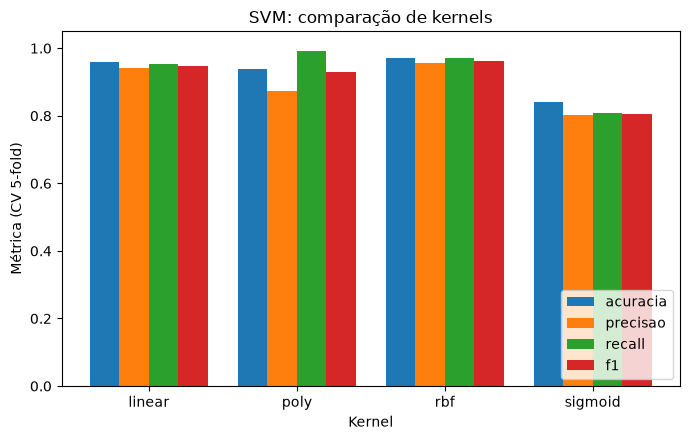

In [23]:
fig, ax = plt.subplots()
x_pos = np.arange(len(kernels))
largura = 0.2
metricas_plot = ["acuracia", "precisao", "recall", "f1"]
for i, metrica in enumerate(metricas_plot):
    ax.bar(x_pos + i * largura, df_svm[metrica], width=largura, label=metrica)
ax.set_xticks(x_pos + largura * (len(metricas_plot) - 1) / 2)
ax.set_xticklabels(kernels)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Kernel")
ax.set_ylabel("Métrica (CV 5-fold)")
ax.set_title("SVM: comparação de kernels")
ax.legend(loc="lower right")
ax.grid(False)
plt.tight_layout()
plt.show()

O kernel _RBF_ obtém o melhor desempenho geral, indicando que a fronteira de decisão real entre exoplanetas confirmados e falsos positivos é não-linear e é bem capturada pela flexibilidade do kernel. O kernel *linear* já apresenta um desempenho competitivo, sugerindo que boa parte da separação entre classes pode ser explicada linearmente, mas o ganho do _RBF_ mostra que há componentes não-lineares relevantes. O kernel polinomial tende a exibir desempenho pior ou forma menos estável, pois é mais sensível à escolha de $d$ e `coef0`, e pode super ou sub-ajustar dependendo dessas escolhas (aqui usamos os valores padrão do scikit-learn, sem busca de hiperparâmetros adicionais). O kernel _sigmoid_ demonstrou ser o mais fraco neste tipo de problema, provavelmente porque foi originalmente elaborado para imitar redes neurais rasas e não é a escolha mais sensata para este problema.

In [24]:
melhor_kernel = df_svm.loc[df_svm["f1"].idxmax(), "kernel"]
print("Melhor kernel (por F1 de teste):", melhor_kernel)

modelo_svm_final = make_pipeline(
    PowerTransformer(method="yeo-johnson"),
    SVC(kernel=melhor_kernel, probability=True, random_state=RANDOM_STATE),
)
resumo_svm_final, _ = avaliar_modelo(modelo_svm_final)
resultados_finais.append(
    resumo_para_linha(f"SVM (kernel={melhor_kernel})", resumo_svm_final)
)
resumo_svm_final

Melhor kernel (por F1 de teste): rbf


,media,desvio
accuracy,0.970395,0.006533
precision,0.957337,0.008733
recall,0.970059,0.008167
f1,0.963648,0.008013
roc_auc,0.995402,0.001725


## 9. Random Forest

### **Experimento:** variação do número de árvores

Random Forest é um método de *bagging*, que treina várias árvores de decisão independentes, cada uma em uma amostra *bootstrap* dos dados e considerando um subconjunto aleatório de features em cada divisão, e agrega as previsões por votação majoritária. O número de árvores (`n_estimators`) controla quantos votos compõem a decisão final. Diferentemente da profundidade da árvore individual, aumentar o número de árvores não aumenta o risco de overfitting, já que cada árvore adicional apenas reduz a variância do conjunto. O principal efeito esperado ao aumentar `n_estimators` é uma melhora, ou uma _estabilização_ do desempenho médio e uma redução da variabilidade entre folds, com retornos decrescentes a partir de um certo ponto.

Não aplicamos pré-processamento, pela mesma justificativa de invariância das árvores de decisão.

In [25]:
# Distribuição mais ou menos uniforme incluindo potências de 2, com 25 elementos no total
n_arvores_lista = sorted({round(2 ** (k / 3)) for k in range(28)})
linhas_rf = []

for n in n_arvores_lista:
    # n_jobs não é definido aqui para evitar paralelismo aninhado com o cross_validate
    # (que já paraleliza entre os folds), o que geraria avisos do joblib
    modelo = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE)
    resumo, resultado = avaliar_modelo(modelo)
    linhas_rf.append(
        {
            "n_estimators": n,
            "acuracia": resumo.loc["accuracy", "media"],
            "std_acuracia": resumo.loc["accuracy", "desvio"],
            "f1": resumo.loc["f1", "media"],
            "std_f1": resumo.loc["f1", "desvio"],
            "roc_auc": resumo.loc["roc_auc", "media"],
        }
    )

df_rf = pd.DataFrame(linhas_rf)
df_rf

,n_estimators,acuracia,std_acuracia,f1,std_f1,roc_auc
0,1,0.928297,0.006668,0.910943,0.008869,0.924934
1,2,0.929067,0.013120,0.906193,0.019232,0.965037
2,3,0.950405,0.004721,0.938166,0.006447,0.977260
3,4,0.951175,0.010747,0.937213,0.015047,0.984116
4,5,0.955209,0.006953,0.944233,0.008654,0.986337
5,6,0.956173,0.009687,0.944487,0.013321,0.987819
6,8,0.961362,0.007949,0.951187,0.010904,0.990974
7,10,0.962130,0.005781,0.952298,0.007849,0.991685
8,13,0.964437,0.005861,0.955619,0.007742,0.992081
9,16,0.963668,0.006722,0.954390,0.008996,0.993124


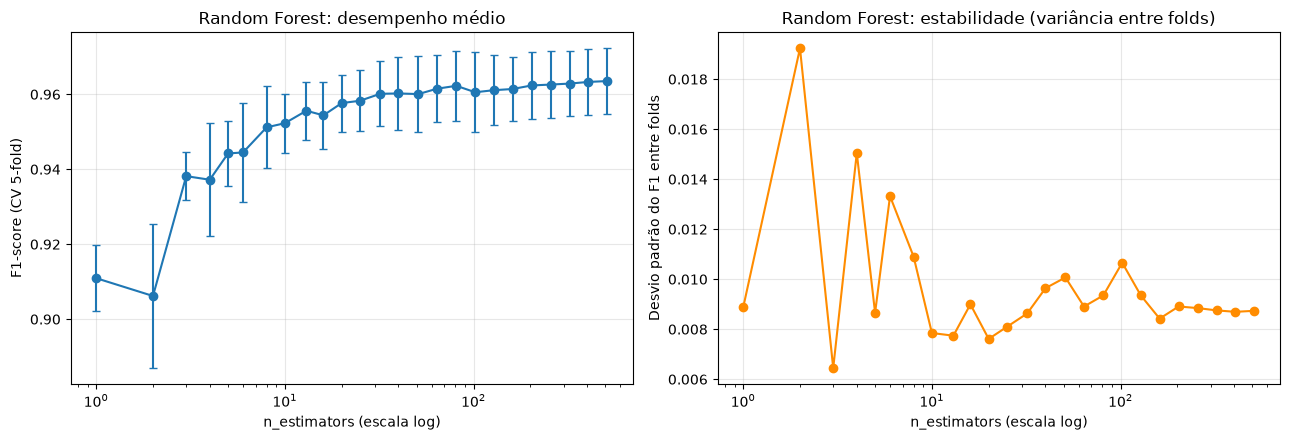

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].errorbar(
    df_rf["n_estimators"], df_rf["f1"], yerr=df_rf["std_f1"], marker="o", capsize=3
)
axes[0].set_xscale("log")
axes[0].set_xlabel("n_estimators (escala log)")
axes[0].set_ylabel("F1-score (CV 5-fold)")
axes[0].set_title("Random Forest: desempenho médio")

axes[1].plot(df_rf["n_estimators"], df_rf["std_f1"], marker="o", color="darkorange")
axes[1].set_xscale("log")
axes[1].set_xlabel("n_estimators (escala log)")
axes[1].set_ylabel("Desvio padrão do F1 entre folds")
axes[1].set_title("Random Forest: estabilidade (variância entre folds)")

plt.tight_layout()
plt.show()

Com poucas árvores, o desempenho médio é mais baixo e a variabilidade entre folds é maior. Conforme `n_estimators` aumenta, o F1-score médio sobe e se estabiliza, e o desvio-padrão entre folds tende a cair, o que se espera de um método de bagging: mais estimadores independentes reduzem a variância do preditor agregado sem introduzir viés adicional. A partir de um certo número de árvores, os ganhos adicionais são marginais, e o custo computacional continua crescendo linearmente, e por isso escolhemos um valor que oferece um bom compromisso entre desempenho e custo.

In [27]:
melhor_f1_rf = df_rf["f1"].max()

# Escolhe o menor n_estimators cujo desempenho já está dentro de 1 desvio-padrão
# do melhor resultado observado, pra evitar escolher no ruído um valor desnecessariamente alto
candidatos = df_rf[
    df_rf["f1"] >= melhor_f1_rf - df_rf.loc[df_rf["f1"].idxmax(), "std_f1"]
]
melhor_n_rf = int(candidatos["n_estimators"].min())
print("n_estimators escolhido:", melhor_n_rf)

# Sem n_jobs=-1 aqui pelo mesmo motivo acima
modelo_rf_final = RandomForestClassifier(
    n_estimators=melhor_n_rf, random_state=RANDOM_STATE
)
resumo_rf_final, _ = avaliar_modelo(modelo_rf_final)
resultados_finais.append(
    resumo_para_linha(f"Random Forest (n={melhor_n_rf})", resumo_rf_final)
)
resumo_rf_final

n_estimators escolhido: 13


,media,desvio
accuracy,0.964437,0.005861
precision,0.963525,0.009905
recall,0.948199,0.018836
f1,0.955619,0.007742
roc_auc,0.992081,0.001239


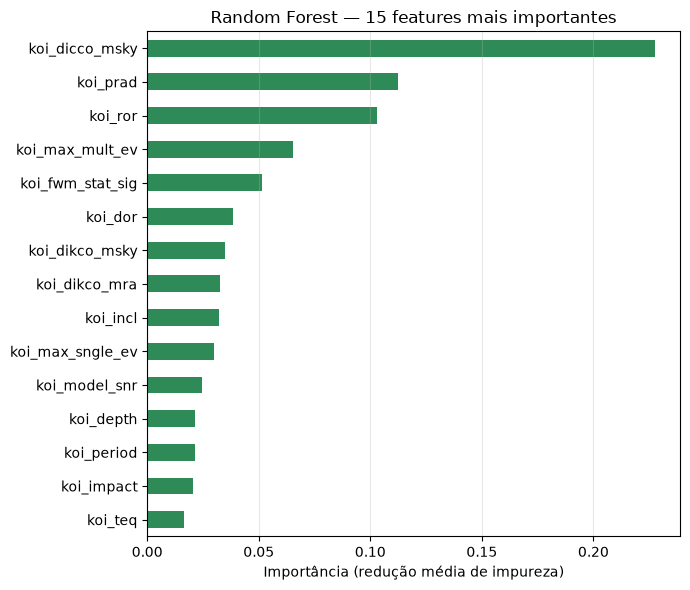

In [28]:
# Importância das features segundo a Random Forest final (treinada em todos os dados)
modelo_rf_final.fit(X, y)
importancias = pd.Series(modelo_rf_final.feature_importances_, index=feature_names)
importancias = importancias.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 6))
importancias.sort_values().plot(kind="barh", ax=ax, color="seagreen")
ax.set_title("Random Forest — 15 features mais importantes")
ax.set_xlabel("Importância (redução média de impureza)")
ax.grid(False, axis="y")
plt.tight_layout()
plt.show()

## 10. Gradient Tree Boosting

### **Experimento:** variação do número de iterações

O _Gradient Boosting_ constrói árvores sequencialmente, onde cada nova árvore é treinada para corrigir os erros cometidos pelo conjunto de árvores já construído. Diferentemente do _Random Forest_, aqui o número de iterações é um hiperparâmetro que pode sim causar overfitting se for grande demais, já que cada iteração adicional tenta reduzir ainda mais o erro de treino, inclusive ajustando-se a ruído.

Não aplicamos pré-processamento, pela mesma justificativa de invariância a transformações monotônicas de árvores.

In [29]:
n_iteracoes_lista = sorted({round(2 ** (k / 3)) for k in range(31)})
linhas_gb = []

for n in n_iteracoes_lista:
    modelo = GradientBoostingClassifier(n_estimators=n, random_state=RANDOM_STATE)
    resumo, _ = avaliar_modelo(modelo)
    resultado_treino = cross_validate(
        modelo, X, y, cv=cv, scoring=SCORING, n_jobs=-1, return_train_score=True
    )
    linhas_gb.append(
        {
            "n_estimators": n,
            "acc_teste": resumo.loc["accuracy", "media"],
            "acc_treino": resultado_treino["train_accuracy"].mean(),
            "f1_teste": resumo.loc["f1", "media"],
            "std_f1_teste": resumo.loc["f1", "desvio"],
            "roc_auc_teste": resumo.loc["roc_auc", "media"],
        }
    )

df_gb = pd.DataFrame(linhas_gb)
df_gb

,n_estimators,acc_teste,acc_treino,f1_teste,std_f1_teste,roc_auc_teste
0,1,0.595540,0.595540,0.000000,0.000000,0.952985
1,2,0.889649,0.892351,0.850250,0.032402,0.966465
2,3,0.937908,0.942329,0.922440,0.007861,0.974351
3,4,0.938867,0.945261,0.923623,0.012225,0.978643
4,5,0.940790,0.948674,0.926374,0.009664,0.982380
5,6,0.945788,0.951942,0.932638,0.012266,0.983252
6,8,0.949633,0.956411,0.937788,0.010837,0.984657
7,10,0.952902,0.958718,0.942026,0.008374,0.985561
8,13,0.954825,0.961313,0.944435,0.006295,0.986827
9,16,0.955594,0.963572,0.945345,0.009590,0.988312


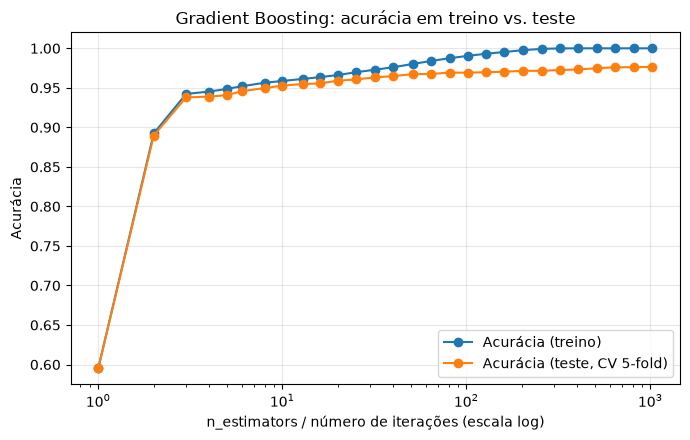

In [30]:
fig, ax = plt.subplots()
ax.plot(
    df_gb["n_estimators"], df_gb["acc_treino"], marker="o", label="Acurácia (treino)"
)
ax.plot(
    df_gb["n_estimators"],
    df_gb["acc_teste"],
    marker="o",
    label="Acurácia (teste, CV 5-fold)",
)
ax.set_xscale("log")
ax.set_xlabel("n_estimators / número de iterações (escala log)")
ax.set_ylabel("Acurácia")
ax.set_title("Gradient Boosting: acurácia em treino vs. teste")
ax.legend()
plt.tight_layout()
plt.show()

Com poucas iterações, o modelo tem alto viés, porque poucas árvores fracas ainda não capturaram os padrões dos dados, e mostra desempenho baixo tanto em treino quanto em teste. Ao aumentar o número de iterações, a acurácia de treino cresce de forma praticamente monotônica, chegando a 100%. A acurácia de teste também cresce, mas com retornos decrescentes: os ganhos acima de ~100 iterações são muito menores que os ganhos entre em torno de 10 e 100. O sinal de overfitting aqui é a crescente distância entre as métricas de treino e teste. Por isso, é vantajoso parar o boosting quando as métricas de avaliação estabilizam. Assim como fizemos para o Random Forest na Seção 9, escolhemos o menor número de iterações cujo desempenho de teste já está dentro de um desvio-padrão do melhor resultado observado, evitando depender de um valor extremo apenas por causa de flutuações da validação cruzada.

In [31]:
melhor_f1_gb = df_gb["f1_teste"].max()

# Mesmo critério parcimonioso usado para o Random Forest (Seção 9): escolhe o
# menor n_estimators cujo desempenho já está dentro de 1 desvio-padrão do melhor
# resultado observado, para não escolher, apenas por ruído da validação cruzada,
# um número de iterações desnecessariamente alto.
candidatos_gb = df_gb[
    df_gb["f1_teste"]
    >= melhor_f1_gb - df_gb.loc[df_gb["f1_teste"].idxmax(), "std_f1_teste"]
]
melhor_n_gb = int(candidatos_gb["n_estimators"].min())
print("n_estimators escolhido:", melhor_n_gb)

modelo_gb_final = GradientBoostingClassifier(
    n_estimators=melhor_n_gb, random_state=RANDOM_STATE
)
resumo_gb_final, _ = avaliar_modelo(modelo_gb_final)
resultados_finais.append(
    resumo_para_linha(f"Gradient Boosting (n={melhor_n_gb})", resumo_gb_final)
)
resumo_gb_final

n_estimators escolhido: 203


,media,desvio
accuracy,0.971548,0.005795
precision,0.958858,0.010460
recall,0.971490,0.011725
f1,0.965057,0.007103
roc_auc,0.995721,0.001317


## 11. Comparação final entre os métodos

Reunimos abaixo, para a melhor configuração de cada método, as métricas médias obtidas na validação cruzada de 5 folds.

In [32]:
tabela_final = pd.DataFrame(resultados_finais).set_index("modelo")
colunas_media = [c for c in tabela_final.columns if not c.endswith("_std")]

tabela_final[colunas_media].round(4)

,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Naïve Bayes,0.9237,0.8541,0.9786,0.9121,0.9832
Decision Tree (max_depth=16),0.9502,0.9368,0.9406,0.9386,0.9383
k-NN (k=5),0.9489,0.9028,0.9791,0.9394,0.9842
SVM (kernel=rbf),0.9704,0.9573,0.9701,0.9636,0.9954
Random Forest (n=13),0.9644,0.9635,0.9482,0.9556,0.9921
Gradient Boosting (n=203),0.9715,0.9589,0.9715,0.9651,0.9957


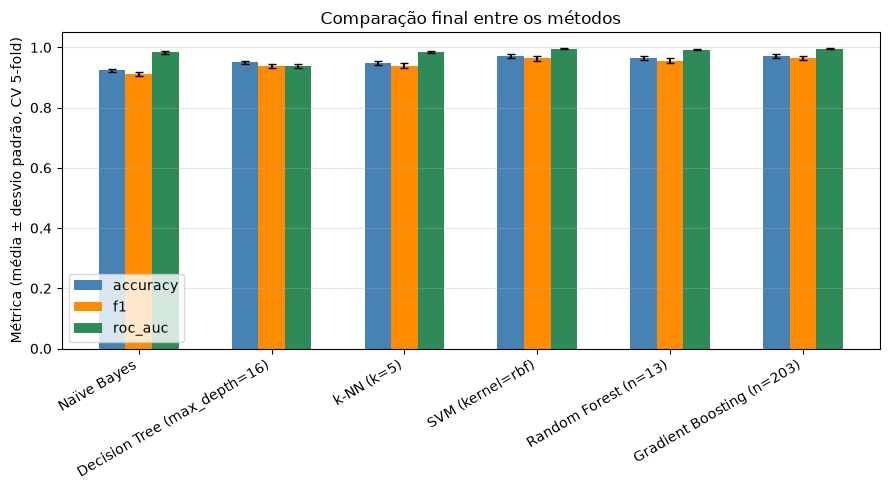

In [33]:
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(tabela_final))
largura = 0.2
metricas_finais = ["accuracy", "f1", "roc_auc"]
cores = ["steelblue", "darkorange", "seagreen"]

for i, metrica in enumerate(metricas_finais):
    ax.bar(
        x_pos + i * largura,
        tabela_final[metrica],
        width=largura,
        yerr=tabela_final[metrica + "_std"],
        capsize=3,
        label=metrica,
        color=cores[i],
    )

ax.set_xticks(x_pos + largura)
ax.set_xticklabels(tabela_final.index, rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Métrica (média ± desvio padrão, CV 5-fold)")
ax.set_title("Comparação final entre os métodos")
ax.legend()
ax.grid(False, axis="x")
plt.tight_layout()
plt.show()

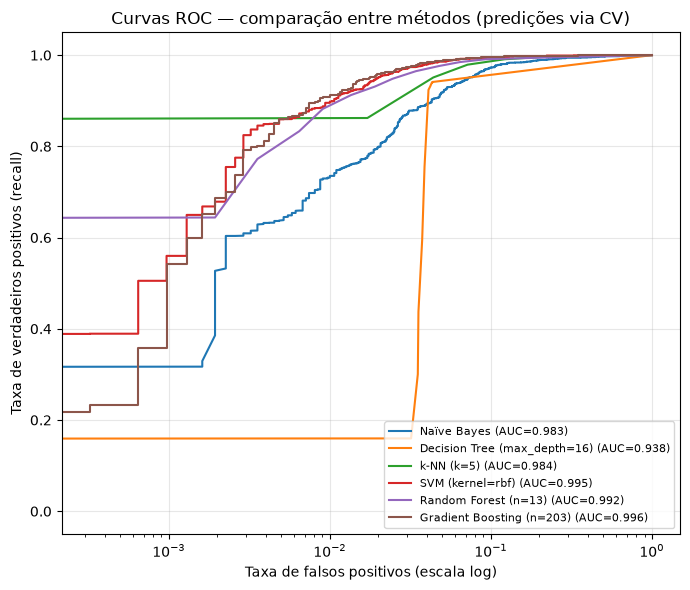

In [34]:
# Curvas ROC de cada método (melhor configuração), obtidas via predições por CV
modelos_finais = {
    "Naïve Bayes": pipeline_nb,
    f"Decision Tree (max_depth={melhor_linha_dt['max_depth']})": modelo_dt_final,
    f"k-NN (k={melhor_k})": modelo_knn_final,
    f"SVM (kernel={melhor_kernel})": modelo_svm_final,
    f"Random Forest (n={melhor_n_rf})": modelo_rf_final,
    f"Gradient Boosting (n={melhor_n_gb})": modelo_gb_final,
}

fig, ax = plt.subplots(figsize=(7, 6))
for nome, modelo in modelos_finais.items():
    y_scores = cross_val_predict(
        modelo, X, y, cv=cv, method="predict_proba", n_jobs=-1
    )[:, 1]
    fpr, tpr, _ = roc_curve(y, y_scores)
    ax.plot(fpr, tpr, label=f"{nome} (AUC={auc(fpr, tpr):.3f})")

ax.set_xscale("log")
ax.set_xlabel("Taxa de falsos positivos (escala log)")
ax.set_ylabel("Taxa de verdadeiros positivos (recall)")
ax.set_title("Curvas ROC — comparação entre métodos (predições via CV)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

### Discussão comparativa

A tabela e o gráfico acima mostram que o desempenho dos seis métodos não é homogêneo. O Naïve Bayes é o método mais fraco em quase todas as métricas, com a menor precisão do grupo (0,854) e o segundo pior F1 (0,912), apesar de ter o maior recall entre os métodos mais simples (0,979); isso indica que o modelo tende a identificar corretamente os exoplanetas confirmados, mas ao custo de uma quantidade razoável de falsos positivos, o que reflete a violação da suposição de independência entre features discutida na Seção 5.

A Decision Tree isolada surpreende ao apresentar o menor AUC-ROC de todo o experimento (0,938), mesmo com acurácia e F1 competitivos (0,950 e 0,939, respectivamente). Isso ocorre porque uma única árvore produz estimativas de probabilidade bastante grosseiras, baseadas apenas na proporção de classes dentro de cada folha; com relativamente poucas folhas, há poucos valores de probabilidade possíveis, o que penaliza a curva ROC, já que essa métrica depende da capacidade do modelo de ranquear exemplos de forma fina ao longo de diversos limiares de decisão. O k-NN, apesar de ter F1 muito parecido com o da árvore (0,939), mostra AUC-ROC bem mais alto (0,984), pois a fração de vizinhos de cada classe permite uma gama mais rica de escores de confiança.

Os três melhores métodos, SVM com kernel RBF, Random Forest e Gradient Boosting, formam o grupo de maior desempenho, com F1 acima de 0,95 e AUC-ROC acima de 0,99. Depois de aplicarmos ao Gradient Boosting o mesmo critério parcimonioso de escolha de hiperparâmetro usado no Random Forest (Seção 10), o número de iterações selecionado foi $n=203$, bem mais moderado do que o valor de maior F1 bruto observado no experimento ($n=1024$), e sem abrir mão de desempenho: o Gradient Boosting segue sendo o método com os melhores valores médios em quase todas as métricas (acurácia de 0,972, F1 de 0,965 e AUC-ROC de 0,996), seguido de perto pelo SVM com kernel RBF (F1 de 0,964, AUC-ROC de 0,995) e pelo Random Forest (F1 de 0,956, AUC-ROC de 0,992). A diferença entre os três é pequena diante da variabilidade observada entre folds, cujos desvios-padrão de F1 ficam todos na faixa de 0,007 a 0,008. Vale notar que o Random Forest apresenta o maior desvio-padrão de recall entre os métodos de melhor desempenho (0,019, contra cerca de 0,008 no SVM e no Gradient Boosting), o que sugere que sua fronteira de decisão para a classe `CONFIRMED` é um pouco mais sensível à partição específica dos dados em cada fold.

Em termos de estabilidade geral, medida pelo desvio-padrão das métricas entre os folds, os métodos de ensemble (Random Forest e Gradient Boosting) e o SVM tendem a ser os mais estáveis, enquanto a Decision Tree isolada é a menos estável, o que é esperado, já que ela depende de um único estimador, sensível a pequenas mudanças no conjunto de treino. O Naïve Bayes e o k-NN ficam em uma posição intermediária. Em termos de sensibilidade a hiperparâmetros, o Random Forest se destaca por ser o método mais robusto: como discutido na Seção 9, seu desempenho satura suavemente e se mantém estável a partir de um número moderado de árvores, sem risco de overfitting adicional ao aumentá-lo ainda mais. Já a Decision Tree, o k-NN, a SVM, dependendo do kernel, e o Gradient Boosting exigem mais cuidado na escolha do hiperparâmetro variado, sob risco de underfitting ou overfitting; o Gradient Boosting em particular, como vimos na Seção 10, precisa de um critério de seleção explícito para evitar que se escolha, apenas por ruído da validação cruzada, um número de iterações desnecessariamente alto.


## 12. Conclusão e escolha do modelo

Os três melhores métodos, SVM com kernel RBF, Random Forest e Gradient Boosting, apresentam desempenho parecido entre si nesta validação cruzada, todos superando claramente o Naïve Bayes, a Decision Tree isolada e o k-NN. Com a escolha parcimoniosa de hiperparâmetro adotada na Seção 10, o Gradient Boosting ($n=203$) obteve os melhores valores médios em quase todas as métricas, mas por uma margem pequena sobre o SVM e o Random Forest, e dentro da faixa de variabilidade observada entre folds.

Considerando esses aspectos, recomendaríamos o Random Forest para uso em um cenário prático de triagem de candidatos a exoplanetas. Seu desempenho é apenas marginalmente inferior ao do Gradient Boosting (F1 de 0,956 contra 0,965, e AUC-ROC de 0,992 contra 0,996), mas o Random Forest não exige nenhuma etapa de pré-processamento, já que é invariante à escala das features, o que simplifica o pipeline de produção e reduz uma fonte adicional de erros ou de vazamento de dados. Além disso, seu único hiperparâmetro relevante, o número de árvores, tem um efeito monotônico e previsível sobre o desempenho, sem risco de overfitting ao aumentá-lo, o que facilita sua escolha em um novo conjunto de dados sem repetir uma busca tão cuidadosa quanto a que foi necessária para o Gradient Boosting nesta seção. O SVM com kernel RBF, por sua vez, depende do `PowerTransformer` definido na Seção 4 e de hiperparâmetros adicionais ($C$, $\gamma$) que não foram explorados neste trabalho. Por fim, diferente da SVM com kernel RBF, o Random Forest permite calcular a importância de cada feature, como fizemos na Seção 9, o que é útil para verificar se o modelo está de fato utilizando sinais fisicamente plausíveis.

O Gradient Boosting continua sendo a alternativa de melhor desempenho bruto e, com um ajuste mais cuidadoso de hiperparâmetros, como `learning_rate` e mecanismos de early stopping baseados em um conjunto de validação, provavelmente manteria essa vantagem de forma mais consistente do que a busca unidimensional feita na Seção 10. Da mesma forma, a SVM com kernel RBF permanece uma opção sólida caso se justifique investir na busca de $C$ e $\gamma$. Em um cenário onde ganhos de poucos décimos percentuais em F1 ou AUC-ROC são relevantes, e onde há orçamento para uma busca de hiperparâmetros mais completa, o Gradient Boosting seria a escolha mais indicada.

Como limitações deste trabalho, não foi feita uma busca exaustiva de hiperparâmetros para nenhum dos métodos, já que o objetivo dos experimentos foi entender o efeito de um hiperparâmetro por vez, como pedido no enunciado; uma busca conjunta, incluindo `learning_rate` e `max_depth` das árvores fracas do Gradient Boosting, ou $C$ e $\gamma$ da SVM, poderia melhorar ainda mais os resultados de alguns métodos. Também não foi realizada seleção de features, e algumas das 41 features poderiam ser redundantes, dado que vimos correlações altas na matriz da Seção 2, o que poderia beneficiar especialmente o Naïve Bayes e o k-NN. Finalmente, o conjunto de dados, apesar de moderadamente desbalanceado, não é extremo; em cenários com desbalanceamento mais severo, técnicas específicas de reponderação de classes ou de reamostragem poderiam ser necessárias.
